In [1]:
import cooler
import cooltools
import bioframe as bf
import bbi
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ggner_3d.cm import CLR_CONNS, get_expected_cis_df, prepare_view_df
from ggner_3d.boundaries import preserved_boundaries_only, make_tads, assign_domain_score, get_insulation_fixed
from ggner_3d.dots_common import compare_loops_with_strength
from ggner_3d.bbi_helpers import stackup_bw_dict, stackup_bw_dict_q


NPROC = 8
resolution = 10000
window = 500_000
clr_ = CLR_CONNS(resolution)

# tad lengths
MAXLEN = 2e6
MINLEN = 2.5e5

rescale_flank = 1
rescale_size = 33 * (2 * rescale_flank + 1)
assert rescale_size % (2 * rescale_flank + 1) == 0 and rescale_size % 2 == 1, "rescale_size"
score_flank=rescale_flank

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import importlib
from ggner_3d import plotting
importlib.reload(plotting)
from ggner_3d.plotting import plot_flanks_start_end_stackup, lineplot_stackup_dict
plotting.update_rcparams()

In [ ]:
# data paths

# CTCF

ctcf_wt_dict = {
'wt_nouv_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_NoUV_REP2.mLb.clN.rpgc.bw'
],
'wt_3h_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_3h_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/WT_3h_REP2.mLb.clN.rpgc.bw'
],
'xpcko_nouv_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_NoUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_NoUV_REP2.mLb.clN.rpgc.bw'
],
'xpcko_3h_ctcf': [
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_3h_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/ctcf/bigwigs_rpgc/XPCKO_3h_REP2.mLb.clN.rpgc.bw'
]
}

# Damage-seq

ds_dict_obs = {
    'wt_nouv_ds': ['/home/carlos/oldies/ner_collab/damageseq/obs0_rpm.1000bp.bw'],
    'wt_3h_ds': ['/home/carlos/oldies/ner_collab/damageseq/obs3_rpm.1000bp.bw'],
}

ds_dict_exp = {
    'wt_nouv_ds': ['/home/carlos/oldies/ner_collab/damageseq/exp0_rpm.1000bp.bw'],
    'wt_3h_ds': ['/home/carlos/oldies/ner_collab/damageseq/exp3_rpm.1000bp.bw'],
}

# XPC

xpc_wt_dict = {
'wt_nouv_xpc': [
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_noUV_REP3.mLb.clN.rpgc.bw'
],
'wt_1h_xpc': [
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_1h_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_1h_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_1h_REP3.mLb.clN.rpgc.bw'
],
'wt_3h_xpc': [
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_3h_REP1.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_3h_REP2.mLb.clN.rpgc.bw',
    '/home/carlos/oldies/ner_collab/xpc_chipseq/bigwigs_rpgc/XPC_WT_3h_REP3.mLb.clN.rpgc.bw'
],
}


# ATAC

atac_wt_dict = {
    'wt_nouv_atac': [
        '/home/carlos/Clone/ggner-3d/misc/WT_noUV.mRp.clN.sorted.RPGC.bs10.sl30.mapq30.ATACshift0.bw',
    ],
    'wt_3h_atac': [
        '/home/carlos/Clone/ggner-3d/misc/WT_UV3h.mRp.clN.sorted.RPGC.bs10.sl30.mapq30.ATACshift0.bw',
    ]
}


### TADs prep

In [4]:
def chrom_to_bin_indices(df, bins_table, bin_column = 'idx1'):
    df = df.copy()
    bins_table['indices'] = bins_table.index
    return pd.merge(df, bins_table, left_on=bin_column, right_on='indices')

insulation_table_ = [
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv'),
    pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WT3h_10000bp.csv'),
]

comparisons = [(0,1)]
comparisons_str = ['WTnoUV_WT3h']
sample_names_str = ['WTnoUV', 'WT3h']
accepted_range = 1

results, dfs = preserved_boundaries_only(
    comparisons=comparisons,
    comparisons_str=comparisons_str,
    sample_names_str=sample_names_str,
    accepted_range=accepted_range,
    insulation_table_=insulation_table_,
    window=window,
)

dfs = [
    chrom_to_bin_indices(df, clr_['WTnoUV'].bins()[:], bin_column='idx1') for df in dfs
]

tads = make_tads(dfs[0][['chrom', 'start', 'end']], maxlen=MAXLEN, minlen=MINLEN).sort_values(['chrom', 'start', 'end']).reset_index(drop=True)

WTnoUV_WT3h: Preserved / Increase ::: 1560
WTnoUV_WT3h: Preserved / Decrease ::: 1002


In [5]:
expected_ = {k: get_expected_cis_df(k, resolution_kb=resolution//1000, label='chrom') for k in sample_names_str}
wtnouv_df = assign_domain_score(
                    tads,
                    clr=clr_['WTnoUV'],
                    expected=expected_['WTnoUV'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight',
                    rescale_flank=rescale_flank,
                    rescale_size=rescale_size,
                    score_flank=score_flank
                    )

wt3h_df = assign_domain_score(
                    tads,
                    clr=clr_['WT3h'],
                    expected=expected_['WT3h'],
                    view_df=prepare_view_df(arm=False),
                    resolution=resolution,
                    nproc=NPROC,
                    clr_weight_name='sweight',
                    rescale_flank=rescale_flank,
                    rescale_size=rescale_size,
                    score_flank=score_flank
                    )

tads_ds_merged = pd.merge(
    wtnouv_df[['chrom', 'start', 'end', 'domain_score']],
    wt3h_df[['chrom', 'start', 'end', 'domain_score']],
    on=['chrom', 'start', 'end'],
    suffixes=('_WTnoUV', '_WT3h')
)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr7', 'chr7'): 121
INFO:coolpuppy:('chr6', 'chr6'): 144
INFO:coolpuppy:('chr8', 'chr8'): 111
INFO:coolpuppy:('chr5', 'chr5'): 141
INFO:coolpuppy:('chr4', 'chr4'): 143
INFO:coolpuppy:('chr3', 'chr3'): 150
INFO:coolpuppy:('chr1', 'chr1'): 202
INFO:coolpuppy:('chr9', 'chr9'): 99
INFO:coolpuppy:('chr2', 'chr2'): 175
INFO:coolpuppy:('chr13', 'chr13'): 67
INFO:coolpuppy:('chr10', 'chr10'): 102
INFO:coolpuppy:('chr11', 'chr11'): 122
INFO:coolpuppy:('chr14', 'chr14'): 82
INFO:coolpuppy:('chr12', 'chr12'): 114
INFO:coolpuppy:('chr16', 'chr16'): 53
INFO:coolpuppy:('chr17', 'chr17'): 67
INFO:coolpuppy:('chr15', 'chr15'): 67
INFO:coolpuppy:('chr21', 'chr21'): 18
INFO:coolpuppy:('chr18', 'chr18'): 56
INFO:coolpuppy:('chr22', 'chr22'): 31
INFO:coolpuppy:('chr19', 'chr19'): 55
INFO:coolpuppy:('chr20', 'chr20'): 56
INFO:coolpuppy:('chrX', 'chrX'): 98
INFO:coolpuppy:Total number of piled up windows: 202
INFO:coolpuppy:Res

In [40]:
tads = tads_ds_merged.copy()
tads['ds_Q'] = pd.qcut(tads['domain_score_WT3h'], q=4, labels=False) + 1

tads = tads.dropna(subset=['ds_Q']).reset_index(drop=True)
print(tads['ds_Q'].value_counts())

flank_ratio = 0.25
tads['flank_size'] = (tads['end'] - tads['start']) * flank_ratio
tads['flank_start'] = tads['start'] - tads['flank_size']
tads['flank_end'] = tads['end'] + tads['flank_size']

ds_Q
4    569
1    569
2    568
3    568
Name: count, dtype: int64


### extended data stats

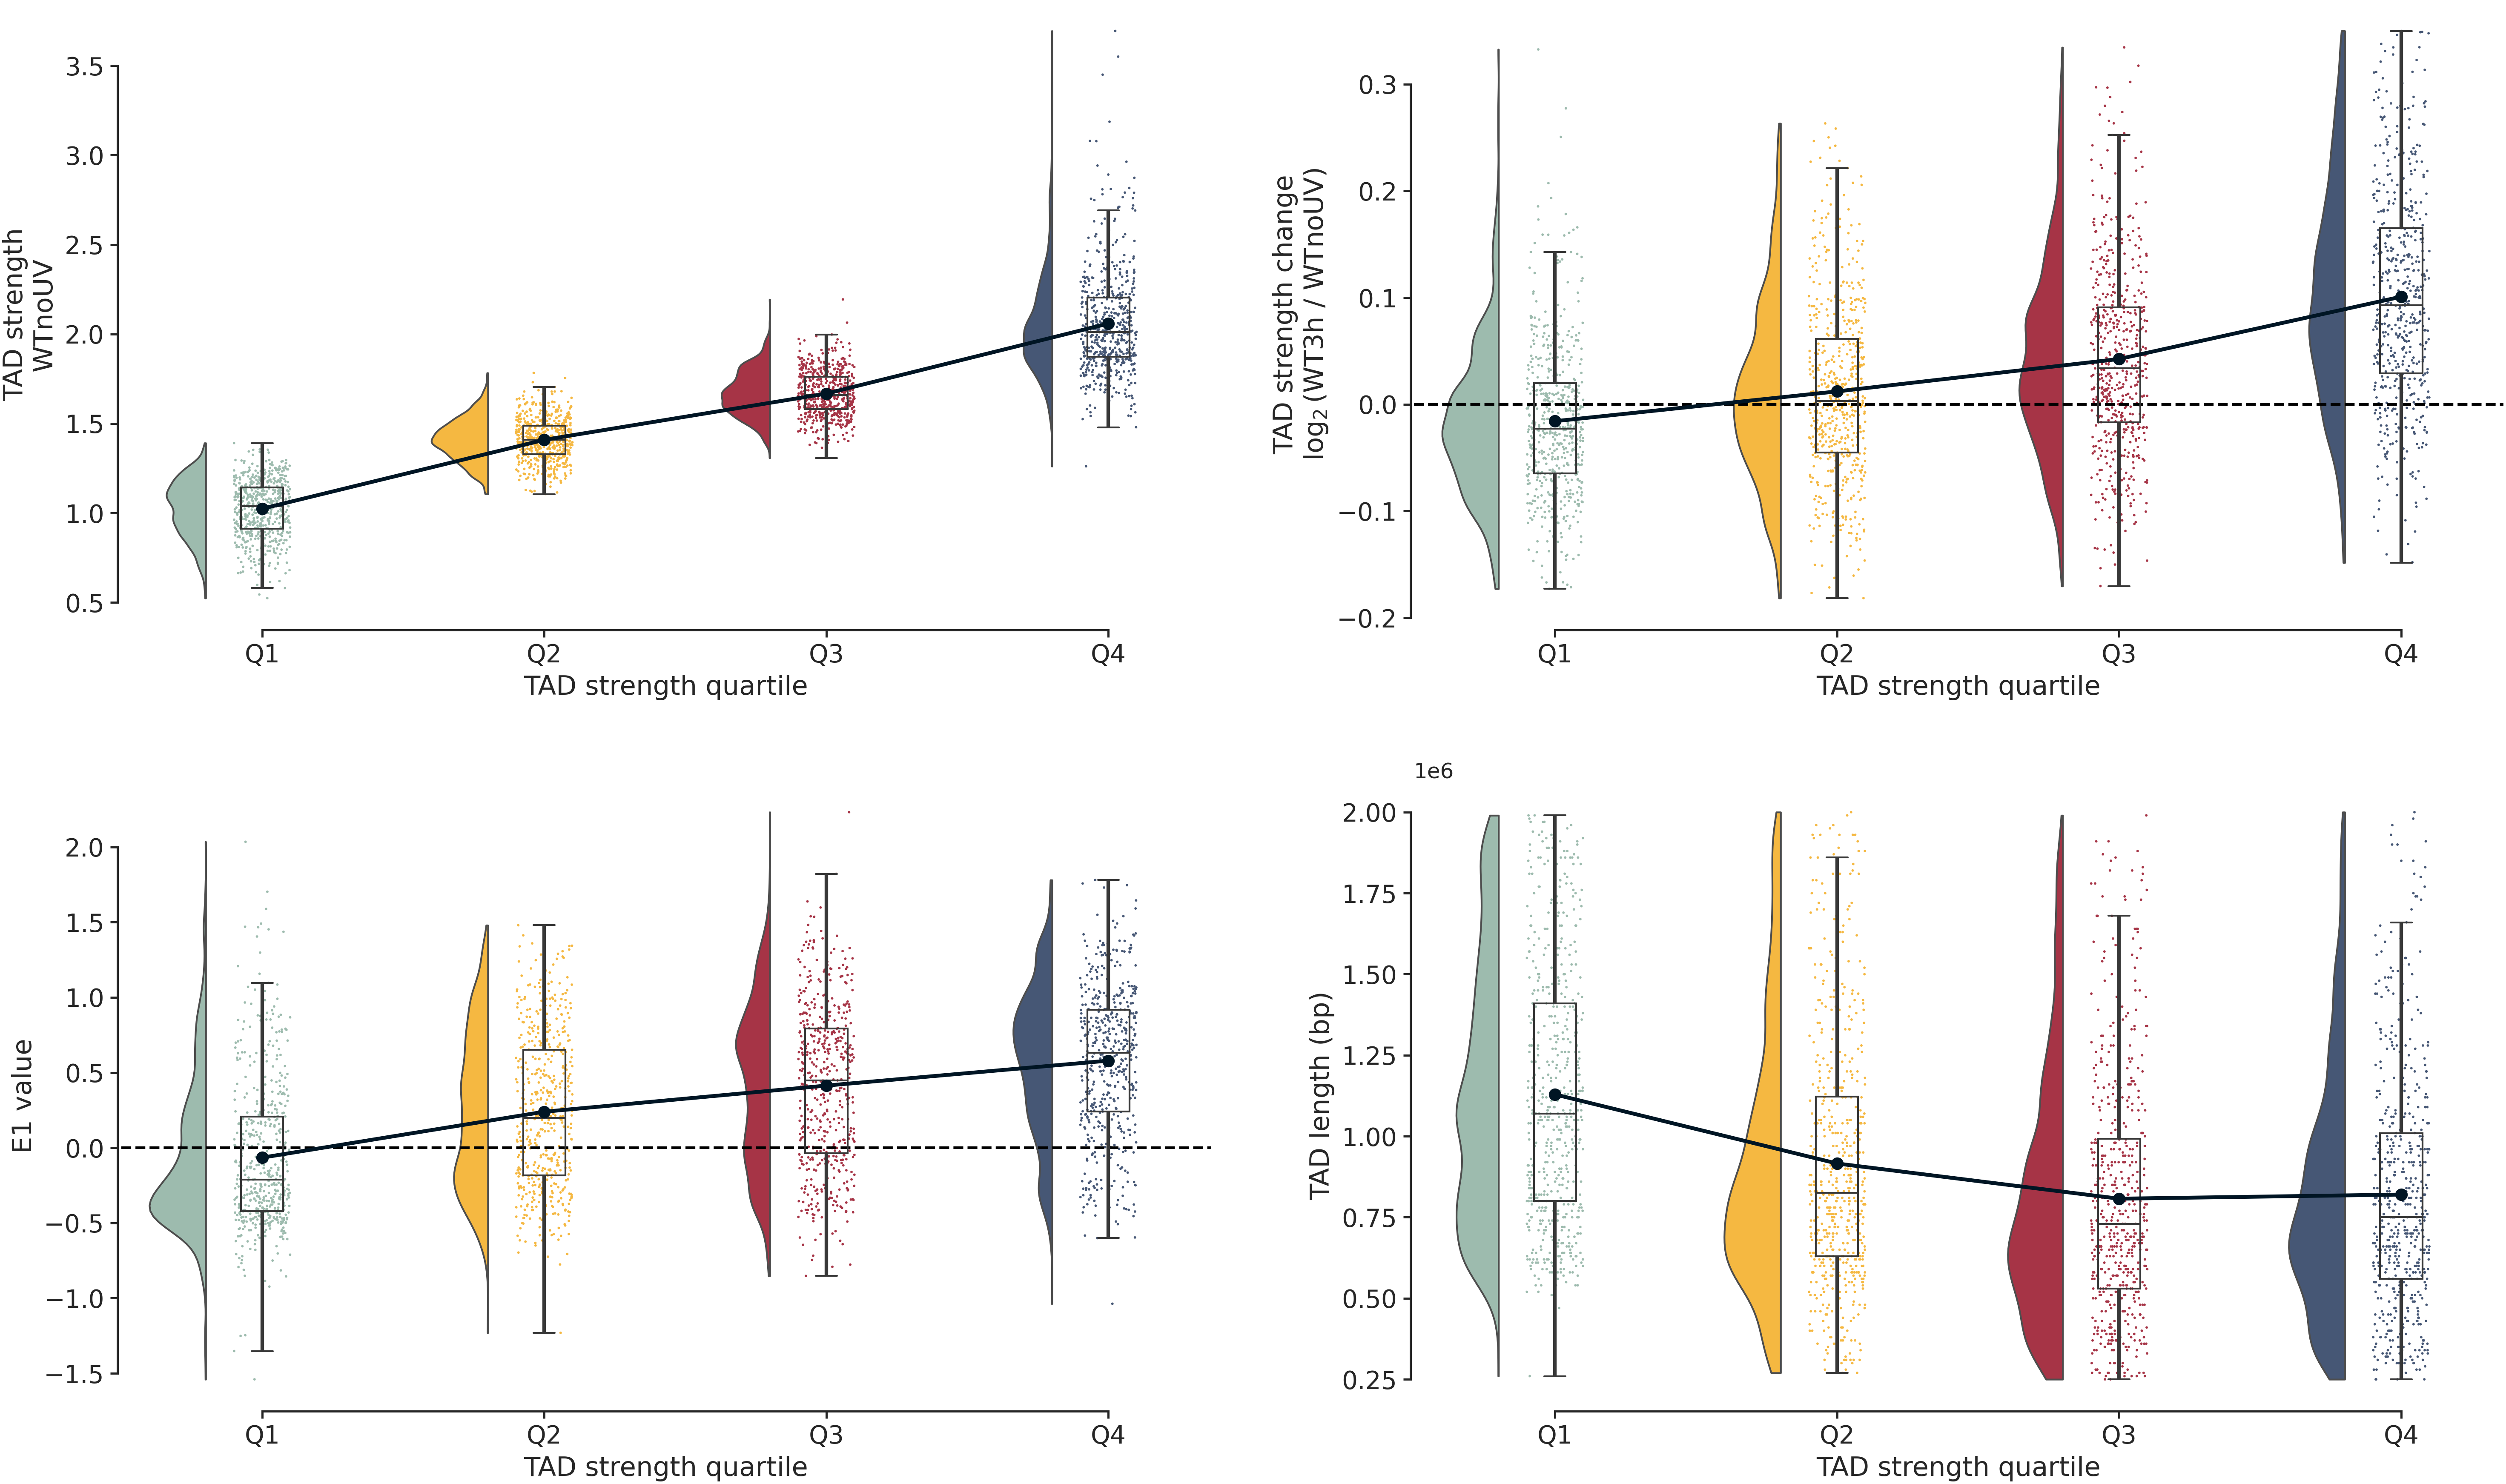

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import ptitprince as pt

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from ggner_3d import plotting
from ggner_3d.cm import get_eig_data
from cooltools.api.saddle import digitize

# ----------------------------
# global style tweaks
# ----------------------------
plotting.update_rcparams()

mpl.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 15,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13,
    'axes.linewidth': 1.2,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

# ----------------------------
# plot config
# ----------------------------
ort = 'v'
sigma = 0.2
pal = list(reversed(plotting.COLORS))

# Stable quartile order
try:
    q_order_raw = sorted(tads['ds_Q'].dropna().unique(), key=lambda x: float(x))
except Exception:
    q_order_raw = sorted(tads['ds_Q'].dropna().unique())

q_map = {q: f'Q{i + 1}' for i, q in enumerate(q_order_raw)}
order = [q_map[q] for q in q_order_raw]

def add_q_label(df, q_col='ds_Q'):
    df = df.copy()
    df['ds_Q_label'] = df[q_col].map(q_map)
    df['ds_Q_label'] = pd.Categorical(
        df['ds_Q_label'],
        categories=order,
        ordered=True
    )
    return df

def raincloud_panel(
    data,
    x,
    y,
    ax,
    order,
    palette,
    ylabel,
    xlabel='TAD strength quartile',
    sigma=0.2,
    box_showfliers=False
):
    ax = pt.RainCloud(
        x=x,
        y=y,
        data=data,
        order=order,
        palette=palette,
        bw=sigma,
        width_viol=0.4,
        ax=ax,
        orient='v',
        move=0.0,
        pointplot=True,
        point_size=1.4,
        linecolor="#001524",
        box_showfliers=box_showfliers
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plotting.despine(ax)
    return ax

# ----------------------------
# merged 2x2 figure
# ----------------------------
fig, axs = plt.subplots(2, 2, figsize=(20, 12))
ax1, ax2, ax3, ax4 = axs.ravel()

# ============================
# panel 1: TAD strength WTnoUV by quartile
# ============================
tads_score = tads.copy()
tads_score = add_q_label(tads_score)

ax1 = raincloud_panel(
    data=tads_score,
    x='ds_Q_label',
    y='domain_score_WTnoUV',
    ax=ax1,
    order=order,
    palette=pal,
    ylabel='TAD strength\nWTnoUV',
    sigma=sigma,
)

# ============================
# panel 2: TAD strength change
# percentile clipping at data level only for this panel
# ============================
tads_plot = tads.copy()
tads_plot['diff'] = np.log2(
    tads_plot['domain_score_WT3h'] / tads_plot['domain_score_WTnoUV'] + 1e-6
)

p1, p99 = np.nanpercentile(tads_plot['diff'], [1, 99])
tads_plot_clipped = tads_plot.loc[
    tads_plot['diff'].between(p1, p99, inclusive='both')
].copy()

tads_plot_clipped = add_q_label(tads_plot_clipped)

ax2 = raincloud_panel(
    data=tads_plot_clipped,
    x='ds_Q_label',
    y='diff',
    ax=ax2,
    order=order,
    palette=pal,
    ylabel='TAD strength change\n' + r'$\log_2$(WT3h / WTnoUV)',
    sigma=sigma,
)

ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)

# ============================
# panel 3: TAD E1 by quartile
# ============================
to_digitize = False

ev_df = get_eig_data('WTnoUV', resolution=100000)[1]
ev_df = ev_df[['chrom', 'start', 'end', 'E1']].copy()

def minmax_norm(s):
    s = np.array(s, dtype=float)
    s_min = np.nanmin(s)
    s_max = np.nanmax(s)
    return (s - s_min) / (s_max - s_min) if s_max != s_min else s

if to_digitize:
    q_range = (0.025, 0.975)
    nbins = 1000

    ev_df = digitize(ev_df, qrange=q_range, n_bins=nbins)[0]
    ev_df = ev_df.loc[ev_df['E1.d'].isin(range(1, nbins + 1))].copy()
    ev_df['E1'] = minmax_norm(ev_df['E1.d'])

    center_value = 0.5
    e1_ylabel = 'Centered E1'
else:
    center_value = 0
    e1_ylabel = 'E1 value'

bf.to_bigwig(
    ev_df[['chrom', 'start', 'end', 'E1']],
    chromsizes=clr_['WTnoUV'].chromsizes,
    outpath='/home/carlos/Clone/ggner-3d/misc/WT_noUV_E1_100kb.bw',
    path_to_binary='/home/carlos/micromamba/envs/deeptools/bin/bedGraphToBigWig'
)

tads_ev = tads.copy()
tads_ev = tads_ev.loc[
    ~tads_ev.chrom.isin(['chr6', 'chr21', 'chr22'])
].reset_index(drop=True)

ev_stack = bbi.stackup(
    '/home/carlos/Clone/ggner-3d/misc/WT_noUV_E1_100kb.bw',
    tads_ev.chrom,
    tads_ev.start,
    tads_ev.end,
    bins=150
)

tads_ev['E1'] = np.nanmean(ev_stack, axis=1)
tads_ev = add_q_label(tads_ev)

ax3 = raincloud_panel(
    data=tads_ev,
    x='ds_Q_label',
    y='E1',
    ax=ax3,
    order=order,
    palette=pal,
    ylabel=e1_ylabel,
    sigma=sigma,
)

ax3.axhline(center_value, color='black', linestyle='--', linewidth=1.5)

# ============================
# panel 4: TAD length by quartile
# ============================
tads_len = tads.copy()
tads_len['length'] = tads_len['end'] - tads_len['start']
tads_len = add_q_label(tads_len)

ax4 = raincloud_panel(
    data=tads_len,
    x='ds_Q_label',
    y='length',
    ax=ax4,
    order=order,
    palette=pal,
    ylabel='TAD length (bp)',
    sigma=sigma,
)

# ----------------------------
# final polish
# ----------------------------
for ax in axs.ravel():
    ax.tick_params(axis='both', which='major', labelsize=14)

fig.tight_layout(w_pad=2.5, h_pad=2.5)

fig.savefig(
    '/home/carlos/Clone/ggner-3d/figs/fig2_rework2/tad_q_metrics_2x2_raincloud.png',
    dpi=300,
    bbox_inches='tight'
)

fig.savefig(
    '/home/carlos/Clone/ggner-3d/figs/fig2_rework2/tad_q_metrics_2x2_raincloud.svg',
    dpi=300,
    bbox_inches='tight'
)

### Loops prep

In [42]:
dots_wt_nouv = pd.read_csv('/home/carlos/Clone/ggner-3d/data/dots/dots_WTnoUV_10000.csv')
dots_wt_3h = pd.read_csv('/home/carlos/Clone/ggner-3d/data/dots/dots_WT3h_10000.csv')

In [43]:

expected_wtnouv = get_expected_cis_df('WTnoUV', resolution_kb=resolution//1000, label='arm')
expected_wt3h = get_expected_cis_df('WT3h', resolution_kb=resolution//1000, label='arm')

view_df = prepare_view_df(arm=True)

loops_dict = compare_loops_with_strength(
    df_a=dots_wt_nouv,
    df_b=dots_wt_3h,
    clr_a=clr_['WTnoUV'],
    clr_b=clr_['WT3h'],
    expected_a=expected_wtnouv,
    expected_b=expected_wt3h,
    view_df_a=view_df,
    view_df_b=view_df,
    resolution=resolution,
    clustering_radius=20000,
    flank=100000,
    clr_weight_name='sweight',
    nproc=NPROC,
    sample_a_name='WTnoUV',
    sample_b_name='WT3h',
    compute_strength=False,
)

In [44]:
# # this is for Q prep on loops wrt their delta strength.

# which_col_for_q = 'delta_strength'

# loops = loops_dict['common_loops'].copy()
# loops['log2_strength_fc'] = np.log2((loops['WT3h_loop_strength'] + 1e-12) / (loops['WTnoUV_loop_strength'] + 1e-12))
# loops['delta_strength'] = loops['WT3h_loop_strength'] - loops['WTnoUV_loop_strength']
# loops['Q'] = pd.qcut(loops[which_col_for_q], q=4, labels=False) + 1
# loops['length'] = loops['end2_WTnoUV'] - loops['start1_WTnoUV']
# loops['flank_size'] = loops['length'] * flank_ratio
# loops['flank_start'] = loops['start1_WTnoUV'] - loops['flank_size']
# loops['flank_end'] = loops['end2_WTnoUV'] + loops['flank_size']
# loops['chrom'] = loops['chrom1_WTnoUV']
# loops['start'] = loops['start1_WTnoUV']
# loops['end'] = loops['end2_WTnoUV']

# loops.Q.value_counts()

In [45]:
loops = loops_dict['common_loops'].copy()
loops['chrom'] = loops['chrom1_WTnoUV']
loops['start'] = loops['start1_WTnoUV']
loops['end'] = loops['end2_WTnoUV']

In [46]:
# loops = pd.read_csv('/home/carlos/Clone/ggner-3d/data/dots/dots_WTnoUV_10000.csv')
# loops['chrom'] = loops['chrom1']
# loops['start'] = loops['start1']
# loops['end'] = loops['end2']

loops['length'] = loops['end'] - loops['start']
overlap = bf.overlap(loops[['chrom', 'start', 'end', 'length']], tads[['chrom', 'start', 'end', 'ds_Q']], suffixes=('_loop', '_tad'), return_overlap=True).dropna(subset=['overlap_start'])
overlap['overlap_length'] = overlap['overlap_end'] - overlap['overlap_start']
overlap['loop_overlap_fraction'] = overlap['overlap_length'] / overlap['length_loop']
overlap = overlap.loc[overlap.loop_overlap_fraction >= 0.9]
overlap['Q_contribution'] = overlap['loop_overlap_fraction'] * overlap['ds_Q_tad']
loop_q = overlap.groupby(['chrom_loop', 'start_loop', 'end_loop'], as_index=False)['Q_contribution'].mean()
loop_q['Q'] = [round(i) for i in loop_q.Q_contribution]
loop_q = loop_q.loc[loop_q.Q.isin([1,2,3,4])].reset_index(drop=True)

loops = loop_q.copy()
loops.rename(columns={'chrom_loop': 'chrom', 'start_loop': 'start', 'end_loop': 'end'}, inplace=True)
loops['flank_size'] = loops['end'] - loops['start']
loops['flank_start'] = loops['start'] - loops['flank_size'] * flank_ratio
loops['flank_end'] = loops['end'] + loops['flank_size'] * flank_ratio
loops.Q = pd.Categorical(loops.Q, categories=[1,2,3,4], ordered=True)

# sample rows wrt min numbered Q category
n_rows_per_category = loops.Q.value_counts().min()
loops = loops.groupby('Q').apply(lambda x: x.sample(n_rows_per_category, random_state=42)).reset_index(drop=True)
loops.Q.value_counts()

Q
1    1736
2    1736
3    1736
4    1736
Name: count, dtype: int64

### per Q

In [47]:
loops.Q.value_counts()

Q
1    1736
2    1736
3    1736
4    1736
Name: count, dtype: int64

In [48]:
tads.ds_Q.value_counts()

ds_Q
4    569
1    569
2    568
3    568
Name: count, dtype: int64

In [49]:
import importlib
from ggner_3d import bbi_helpers
importlib.reload(bbi_helpers)
from ggner_3d.bbi_helpers import stackup_bw_dict_q

nbins = 600

In [50]:
mean_per_q = False

In [24]:
# q stackups - TADS

wt_nouv_ctcf_stackup_tads_q = stackup_bw_dict_q(ctcf_wt_dict['wt_nouv_ctcf'], tads, q_col='ds_Q', mean_per_q=mean_per_q, nbins=nbins)
wt_3h_ctcf_stackup_tads_q = stackup_bw_dict_q(ctcf_wt_dict['wt_3h_ctcf'], tads, q_col='ds_Q', mean_per_q=mean_per_q, nbins=nbins)

wt_nouv_ds_stackup_tads_q = stackup_bw_dict_q(ds_dict_obs['wt_nouv_ds'], tads, q_col='ds_Q', mean_per_q=mean_per_q, nbins=nbins)
wt_3h_ds_stackup_tads_q = stackup_bw_dict_q(ds_dict_obs['wt_3h_ds'], tads, q_col='ds_Q', mean_per_q=mean_per_q, nbins=nbins)

wt_nouv_xpc_stackup_tads_q = stackup_bw_dict_q(xpc_wt_dict['wt_nouv_xpc'], tads, q_col='ds_Q', mean_per_q=mean_per_q, nbins=nbins)
wt_1h_xpc_stackup_tads_q = stackup_bw_dict_q(xpc_wt_dict['wt_1h_xpc'], tads, q_col='ds_Q', mean_per_q=mean_per_q, nbins=nbins)
wt_3h_xpc_stackup_tads_q = stackup_bw_dict_q(xpc_wt_dict['wt_3h_xpc'], tads, q_col='ds_Q', mean_per_q=mean_per_q, nbins=nbins)

atac_wt_nouv_stackup_tads_q = stackup_bw_dict_q(atac_wt_dict['wt_nouv_atac'], tads, q_col='ds_Q', mean_per_q=mean_per_q, nbins=nbins)
atac_wt_3h_stackup_tads_q = stackup_bw_dict_q(atac_wt_dict['wt_3h_atac'], tads, q_col='ds_Q', mean_per_q=mean_per_q, nbins=nbins)

# diffs

wt_repair_tads = {q: wt_nouv_ds_stackup_tads_q[q] - wt_3h_ds_stackup_tads_q[q] for q in wt_nouv_ds_stackup_tads_q.keys()}

xpc_1h_diff_stackup_tads_q = {q: wt_1h_xpc_stackup_tads_q[q] - wt_nouv_xpc_stackup_tads_q[q] for q in wt_nouv_xpc_stackup_tads_q.keys()}

xpc_3h_diff_stackup_tads_q = {q: wt_3h_xpc_stackup_tads_q[q] - wt_nouv_xpc_stackup_tads_q[q] for q in wt_nouv_xpc_stackup_tads_q.keys()}

atac_diff_stackup_tads_q = {q: atac_wt_3h_stackup_tads_q[q] - atac_wt_nouv_stackup_tads_q[q] for q in atac_wt_nouv_stackup_tads_q.keys()}

ctcf_3h_nouv_diff_stackup_tads_q = {q: wt_3h_ctcf_stackup_tads_q[q] - wt_nouv_ctcf_stackup_tads_q[q] for q in wt_nouv_ctcf_stackup_tads_q.keys()}

# wt_repair_tads = {
#     q: np.nanmean(wt_nouv_ds_stackup_tads_q[q], axis=0) - np.nanmean(wt_3h_ds_stackup_tads_q[q], axis=0)
#     for q in wt_nouv_ds_stackup_tads_q.keys()
# }

# xpc_1h_diff_stackup_tads_q = {
#     q: np.nanmean(wt_1h_xpc_stackup_tads_q[q], axis=0) - np.nanmean(wt_nouv_xpc_stackup_tads_q[q], axis=0)
#     for q in wt_nouv_xpc_stackup_tads_q.keys()
# }

# xpc_3h_diff_stackup_tads_q = {
#     q: np.nanmean(wt_3h_xpc_stackup_tads_q[q], axis=0) - np.nanmean(wt_nouv_xpc_stackup_tads_q[q], axis=0)
#     for q in wt_nouv_xpc_stackup_tads_q.keys()
# }

# atac_diff_stackup_tads_q = {
#     q: np.nanmean(atac_wt_3h_stackup_tads_q[q], axis=0) - np.nanmean(atac_wt_nouv_stackup_tads_q[q], axis=0)
#     for q in atac_wt_nouv_stackup_tads_q.keys()
# }

# ctcf_3h_nouv_diff_stackup_tads_q = {
#     q: np.nanmean(wt_3h_ctcf_stackup_tads_q[q], axis=0) - np.nanmean(wt_nouv_ctcf_stackup_tads_q[q], axis=0)
#     for q in wt_nouv_ctcf_stackup_tads_q.keys()
# }

In [25]:
# q stackups - loops

wt_nouv_ctcf_stackup_loops_q = stackup_bw_dict_q(ctcf_wt_dict['wt_nouv_ctcf'], loops, q_col='Q', mean_per_q=mean_per_q, nbins=nbins)
wt_3h_ctcf_stackup_loops_q = stackup_bw_dict_q(ctcf_wt_dict['wt_3h_ctcf'], loops, q_col='Q', mean_per_q=mean_per_q, nbins=nbins)

wt_nouv_ds_stackup_loops_q = stackup_bw_dict_q(ds_dict_obs['wt_nouv_ds'], loops, q_col='Q', mean_per_q=mean_per_q, nbins=nbins)
wt_3h_ds_stackup_loops_q = stackup_bw_dict_q(ds_dict_obs['wt_3h_ds'], loops, q_col='Q', mean_per_q=mean_per_q, nbins=nbins)

wt_nouv_xpc_stackup_loops_q = stackup_bw_dict_q(xpc_wt_dict['wt_nouv_xpc'], loops, q_col='Q', mean_per_q=mean_per_q, nbins=nbins)
wt_1h_xpc_stackup_loops_q = stackup_bw_dict_q(xpc_wt_dict['wt_1h_xpc'], loops, q_col='Q', mean_per_q=mean_per_q, nbins=nbins)
wt_3h_xpc_stackup_loops_q = stackup_bw_dict_q(xpc_wt_dict['wt_3h_xpc'], loops, q_col='Q', mean_per_q=mean_per_q, nbins=nbins)

atac_wt_nouv_stackup_loops_q = stackup_bw_dict_q(atac_wt_dict['wt_nouv_atac'], loops, q_col='Q', mean_per_q=mean_per_q, nbins=nbins)
atac_wt_3h_stackup_loops_q = stackup_bw_dict_q(atac_wt_dict['wt_3h_atac'], loops, q_col='Q', mean_per_q=mean_per_q, nbins=nbins)

# diffs

wt_repair_loops = {q: wt_nouv_ds_stackup_loops_q[q] - wt_3h_ds_stackup_loops_q[q] for q in wt_nouv_ds_stackup_loops_q.keys()}
xpc_1h_diff_stackup_loops_q = {q: wt_1h_xpc_stackup_loops_q[q] - wt_nouv_xpc_stackup_loops_q[q] for q in wt_nouv_xpc_stackup_loops_q.keys()}
xpc_3h_diff_stackup_loops_q = {q: wt_3h_xpc_stackup_loops_q[q] - wt_nouv_xpc_stackup_loops_q[q] for q in wt_nouv_xpc_stackup_loops_q.keys()}
atac_diff_stackup_loops_q = {q: atac_wt_3h_stackup_loops_q[q] - atac_wt_nouv_stackup_loops_q[q] for q in atac_wt_nouv_stackup_loops_q.keys()}
ctcf_3h_nouv_diff_stackup_loops_q = {q: wt_3h_ctcf_stackup_loops_q[q] - wt_nouv_ctcf_stackup_loops_q[q] for q in wt_nouv_ctcf_stackup_loops_q
.keys()}

# wt_repair_loops = {
#     q: np.nanmean(wt_nouv_ds_stackup_loops_q[q], axis=0) - np.nanmean(wt_3h_ds_stackup_loops_q[q], axis=0)
#     for q in wt_nouv_ds_stackup_loops_q.keys()
# }

# xpc_1h_diff_stackup_loops_q = {
#     q: np.nanmean(wt_1h_xpc_stackup_loops_q[q], axis=0) - np.nanmean(wt_nouv_xpc_stackup_loops_q[q], axis=0)
#     for q in wt_nouv_xpc_stackup_loops_q.keys()
# }

# xpc_3h_diff_stackup_loops_q = {
#     q: np.nanmean(wt_3h_xpc_stackup_loops_q[q], axis=0) - np.nanmean(wt_nouv_xpc_stackup_loops_q[q], axis=0)
#     for q in wt_nouv_xpc_stackup_loops_q.keys()
# }

# atac_diff_stackup_loops_q = {
#     q: np.nanmean(atac_wt_3h_stackup_loops_q[q], axis=0) - np.nanmean(atac_wt_nouv_stackup_loops_q[q], axis=0)
#     for q in atac_wt_nouv_stackup_loops_q.keys()
# }

# ctcf_3h_nouv_diff_stackup_loops_q = {
#     q: np.nanmean(wt_3h_ctcf_stackup_loops_q[q], axis=0) - np.nanmean(wt_nouv_ctcf_stackup_loops_q[q], axis=0)
#     for q in wt_nouv_ctcf_stackup_loops_q.keys()
# }

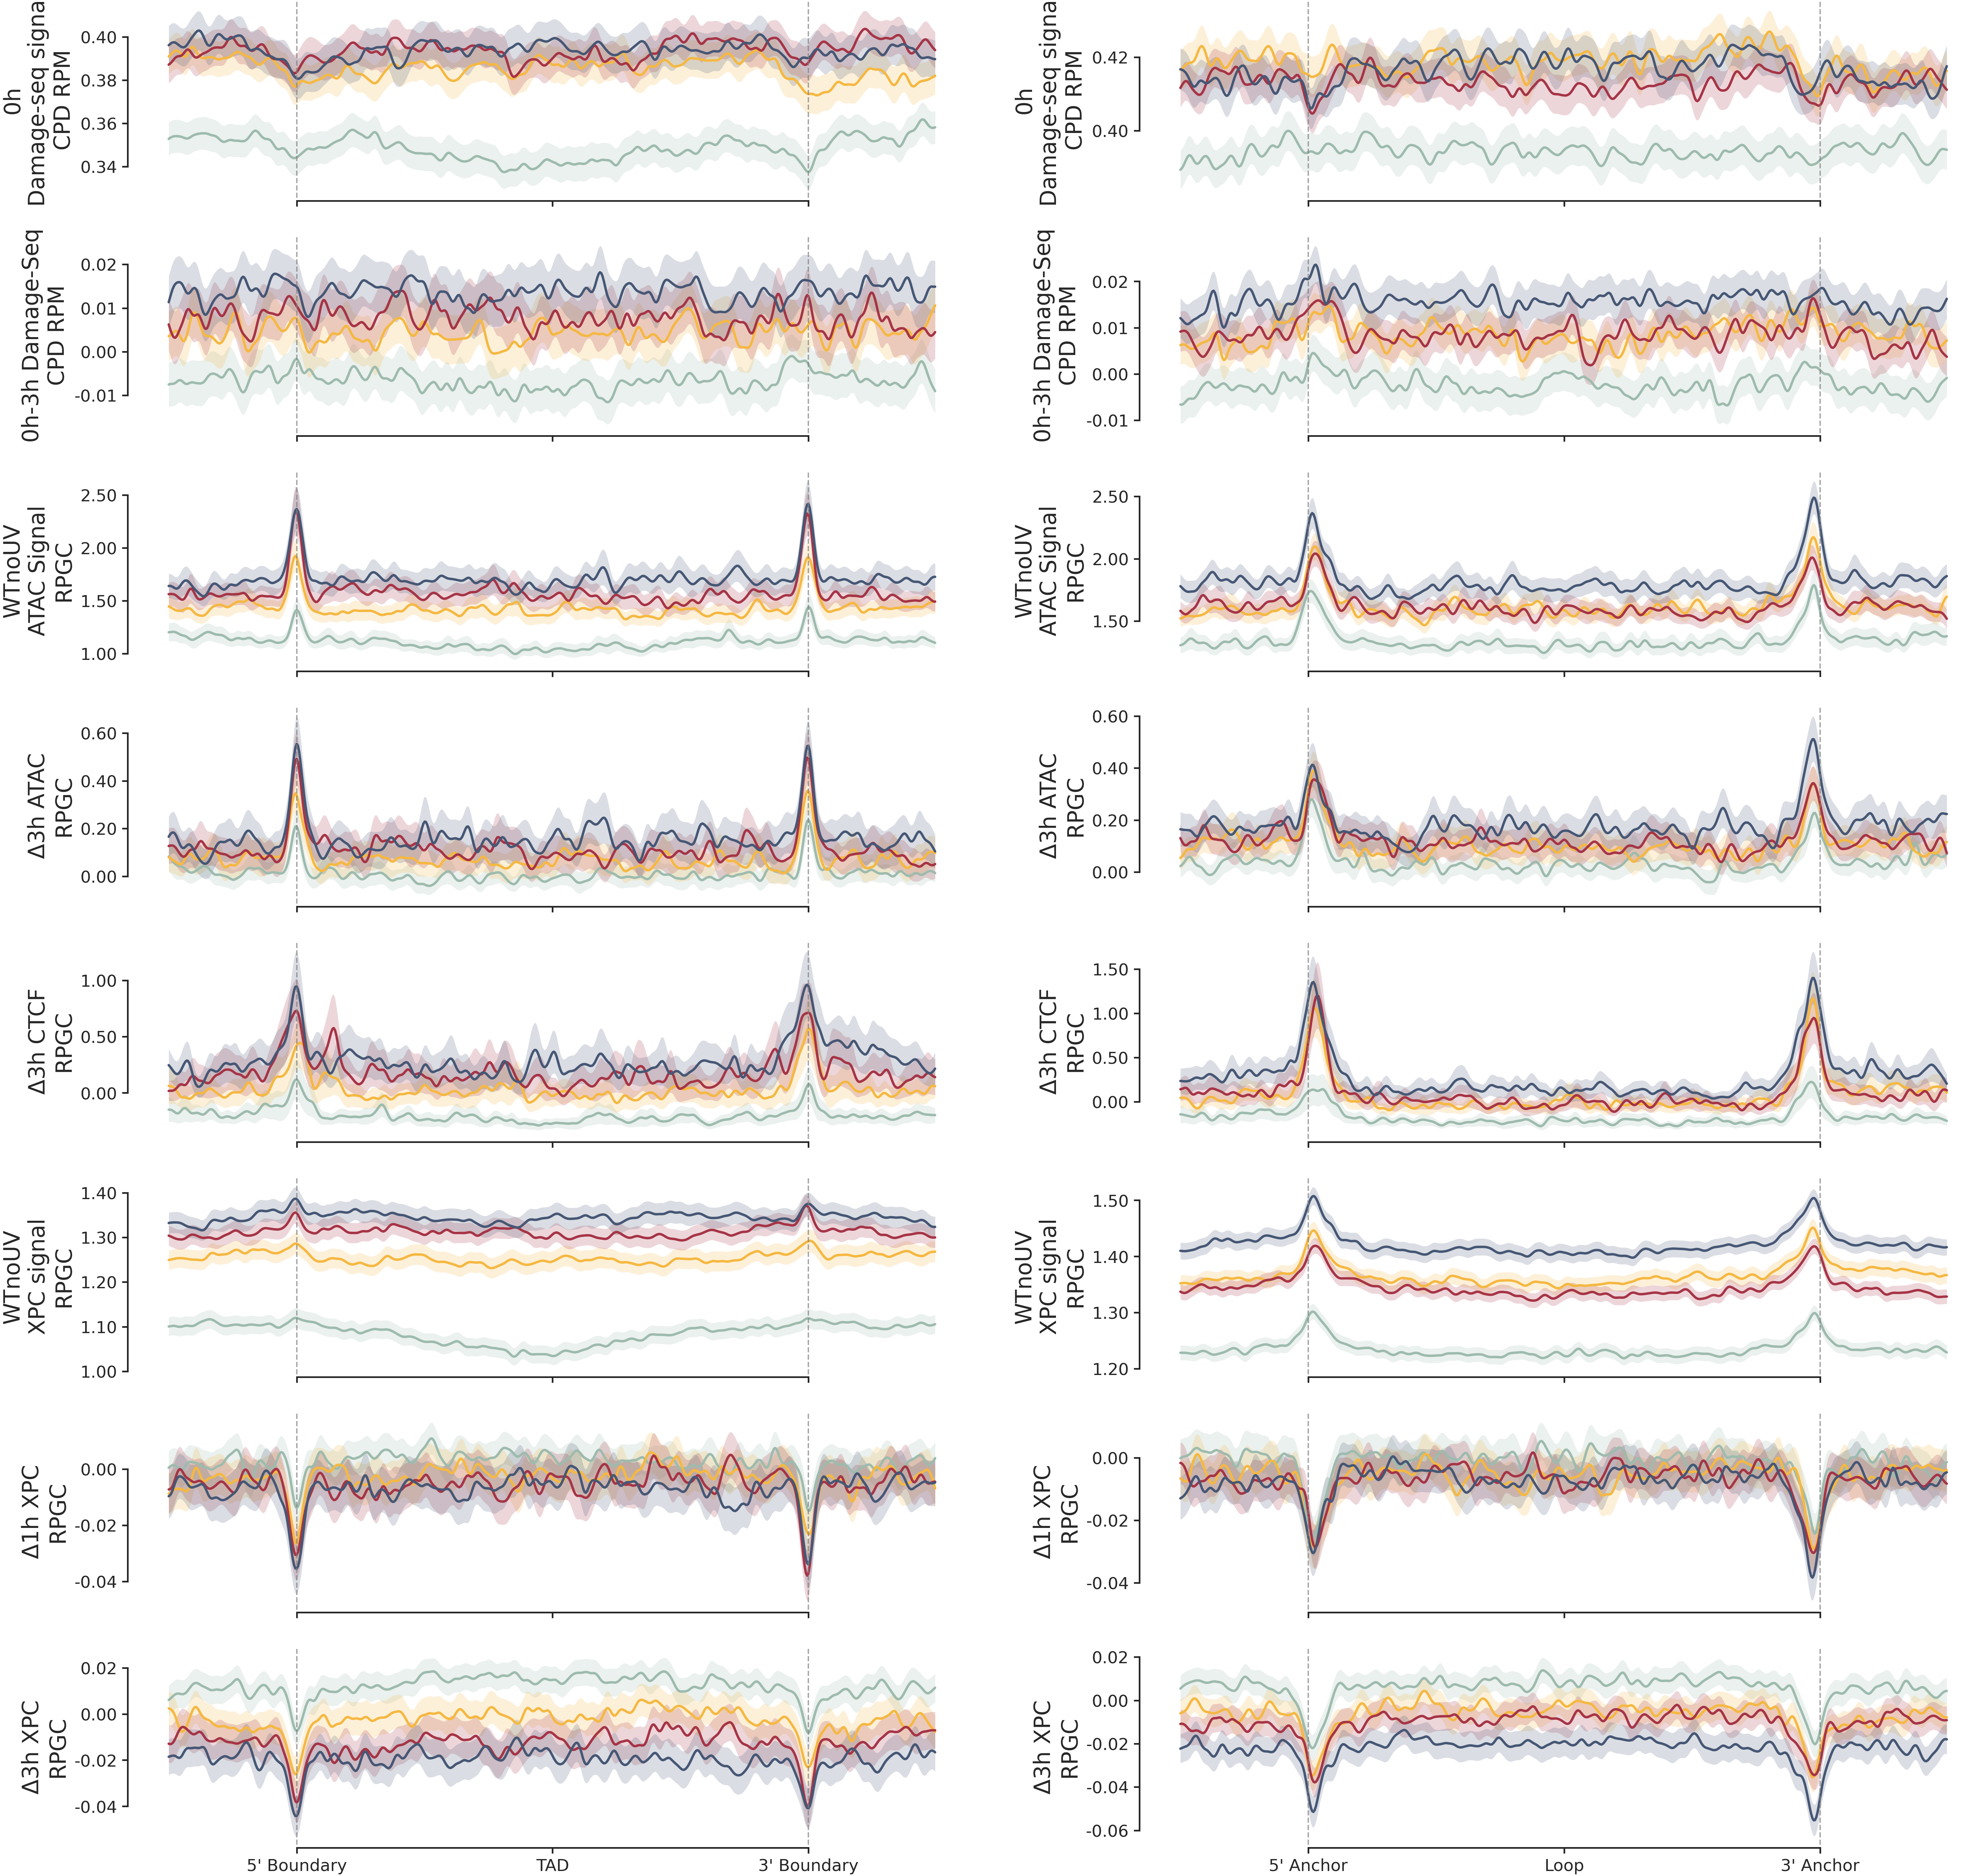

In [46]:
colors = list(reversed(plotting.COLORS))
fig, axs = plt.subplots(8, 2, figsize=(24, 24), sharex='col')

common_params = {
    'plot_kwargs': {'linewidth': 1.75},
    'colors': list(reversed(plotting.COLORS)),
    'smooth_sigma': 3.0,
}

# Damage-Seq TADs

lineplot_stackup_dict(
    wt_nouv_ds_stackup_tads_q,
    ax=axs[0, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Damage-seq Signal\nRPM',
    y_title='0h\nDamage-seq signal\nCPD RPM',
    structure_type='TAD',
    **common_params
)

lineplot_stackup_dict(
    wt_repair_tads,
    ax=axs[1, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ Damage-Seq',
    y_title='0h-3h Damage-Seq\nCPD RPM',
    structure_type='TAD',
    **common_params
)

# Damage-Seq Loops
lineplot_stackup_dict(
    wt_nouv_ds_stackup_loops_q,
    ax=axs[0, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Damage-seq Signal\nRPM',
    y_title='0h\nDamage-seq signal\nCPD RPM',
    structure_type='Loop',
    **common_params
)

lineplot_stackup_dict(
    wt_repair_loops,
    ax=axs[1, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ Damage-Seq',
    y_title='0h-3h Damage-Seq\nCPD RPM',
    structure_type='Loop',
    **common_params
)

# ATAC TADs
lineplot_stackup_dict(
    atac_wt_nouv_stackup_tads_q,
    ax=axs[2, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='ATAC-seq Signal\nRPGC',
    y_title='WTnoUV\nATAC Signal\nRPGC',
    structure_type='TAD',
    **common_params
)

lineplot_stackup_dict(
    atac_diff_stackup_tads_q,
    ax=axs[3, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ ATAC-seq',
    y_title='Δ3h ATAC\nRPGC',
    structure_type='TAD',
    **common_params
)

# ATAC Loops
lineplot_stackup_dict(
    atac_wt_nouv_stackup_loops_q,
    ax=axs[2, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='ATAC-seq Signal\nRPGC',
    y_title='WTnoUV\nATAC Signal\nRPGC',
    structure_type='Loop',
    **common_params
)

lineplot_stackup_dict(
    atac_diff_stackup_loops_q,
    ax=axs[3, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ ATAC-seq',
    y_title='Δ3h ATAC\nRPGC',
    structure_type='Loop',
    **common_params
)

# Delta CTCF TADs

lineplot_stackup_dict(
    ctcf_3h_nouv_diff_stackup_tads_q,
    ax=axs[4, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ CTCF ChIP-seq',
    y_title='Δ3h CTCF\nRPGC',
    structure_type='TAD',
    **common_params
)

# Delta CTCF Loops

lineplot_stackup_dict(
    ctcf_3h_nouv_diff_stackup_loops_q,
    ax=axs[4, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ CTCF ChIP-seq',
    y_title='Δ3h CTCF\nRPGC',
    structure_type='Loop',
    **common_params
)

# XPC TADs
lineplot_stackup_dict(
    wt_nouv_xpc_stackup_tads_q,
    ax=axs[5, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='XPC ChIP-seq Signal\nRPGC',
    y_title='WTnoUV\nXPC signal\nRPGC',
    structure_type='TAD',
    **common_params
)

lineplot_stackup_dict(
    xpc_1h_diff_stackup_tads_q,
    ax=axs[6, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ XPC ChIP-seq (1h)',
    y_title='Δ1h XPC\nRPGC',
    structure_type='TAD',
    **common_params
)

lineplot_stackup_dict(
    xpc_3h_diff_stackup_tads_q,
    ax=axs[7, 0],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ XPC ChIP-seq (3h)',
    y_title='Δ3h XPC\nRPGC',
    structure_type='TAD',
    **common_params
)

# XPC Loops
lineplot_stackup_dict(
    wt_nouv_xpc_stackup_loops_q,
    ax=axs[5, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='XPC ChIP-seq Signal\nRPGC',
    y_title='WTnoUV\nXPC signal\nRPGC',
    structure_type='Loop',
    **common_params
)

lineplot_stackup_dict(
    xpc_1h_diff_stackup_loops_q,
    ax=axs[6, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ XPC ChIP-seq (1h)',
    y_title='Δ1h XPC\nRPGC',
    structure_type='Loop',
    **common_params
)

lineplot_stackup_dict(
    xpc_3h_diff_stackup_loops_q,
    ax=axs[7, 1],
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Δ XPC ChIP-seq (3h)',
    y_title='Δ3h XPC\nRPGC',
    structure_type='Loop',
    **common_params
)

# --- Axis cosmetics ---
for ax in axs.flatten():
    plotting.despine(ax=ax)
    ax.set_xlabel("")
    # make x, y labels bigger
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    # remove legends
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    # make x and y ticks bigger
    ax.tick_params(axis='both', which='major', labelsize=12)

    # make y ticks 2 digits after comma
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig2_rework2/stackups_q_tads_loops.png', dpi=300, bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig2_rework2/stackups_q_tads_loops.svg', dpi=300, bbox_inches='tight')

### Hi-C pileups

In [ ]:

pileups = {
    i: [] for i in range(1, 5)
}
from coolpuppy import coolpup

expected_nouv = get_expected_cis_df('WTnoUV', label='arm', resolution_kb=10)
clr_nouv = clr_['WTnoUV']
expected_uv = get_expected_cis_df('WT3h', label='arm', resolution_kb=10)
clr_uv = clr_['WT3h']

view_df = prepare_view_df(arm=True)

for i in range(1, 5):
    tads_q = tads[tads.ds_Q == i][['chrom', 'start', 'end']].reset_index(drop=True)

    cc = coolpup.CoordCreator(tads_q, resolution=10000, features_format='bed', local=True, rescale_flank=rescale_flank)
    pup_uv = coolpup.PileUpper(clr_uv, cc, expected=expected_uv, view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc=6).pileupsWithControl()
    pup_nouv = coolpup.PileUpper(clr_nouv, cc, expected=expected_nouv, view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc=6).pileupsWithControl()
    pileups[i] = (pup_nouv, pup_uv)

SyntaxError: 'break' outside loop (2922856958.py, line 1)

In [ ]:
# two-row pileup panel
# row 1 = log2 pileups[i][0]
# row 2 = log2 fold-change = log2(pileups[i][1] / pileups[i][0])

eps = 1e-6

# precompute matrices
all_base = []
all_diffs = []
for i in range(1, 5):
    base_mtx = np.log2(pileups[i][0]['data'][0] + eps)
    diff_mtx = np.log2((pileups[i][1]['data'][0] + eps) / (pileups[i][0]['data'][0] + eps))
    
    all_base.append(base_mtx)
    all_diffs.append(diff_mtx)

# color scales
base_vmin, base_vmax = -1.5, 1.5
diff_vmin, diff_vmax = -0.1, 0.1

aspect_ratio = 4.8
fig, axs = plt.subplots(2, 4, figsize=(4 * aspect_ratio, 2 * aspect_ratio))
plotting.update_rcparams()

for i in range(1, 5):
    # -------------------------
    # first row: base heatmaps
    # -------------------------
    base_mtx_comp = all_base[i - 1]

    ax = plotting.hic_upper_triangle(
        base_mtx_comp,
        cmap="vlag",
        center=0,
        vmin=base_vmin,
        vmax=base_vmax,
        ax=axs[0, i - 1],
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
    )

    n = base_mtx_comp.shape[0]
    bins = np.array([int(n * 0.33), int(n * 0.5), int(n * 0.66)])

    ax.axis("on")
    ax.set_xticks(2 * bins)
    ax.set_xticks(
        2 * bins,
        labels=["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"]
    )
    ax.set_xlabel(f"Q{i}", labelpad=5)
    ax.tick_params(axis='x', labelsize=9.5)

    ax.set_yticks([])
    ax.get_yaxis().set_visible(False)

    cbar = ax.figure.axes[-1]
    cbar.set_ylabel(r"$\log_{2}$Obs/Exp", labelpad=5)

    plotting.despine(ax)

    # -------------------------
    # second row: L2FC heatmaps
    # -------------------------
    diff_mtx_comp = all_diffs[i - 1]

    ax = plotting.hic_upper_triangle(
        diff_mtx_comp,
        cmap="vlag",
        center=0,
        vmin=diff_vmin,
        vmax=diff_vmax,
        ax=axs[1, i - 1],
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
    )

    n = diff_mtx_comp.shape[0]
    bins = np.array([int(n * 0.33), int(n * 0.5), int(n * 0.66)])

    ax.axis("on")
    ax.set_xticks(2 * bins)
    ax.set_xticks(
        2 * bins,
        labels=["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"]
    )
    ax.set_xlabel(f"Q{i}", labelpad=5)
    ax.tick_params(axis='x', labelsize=9.5)

    ax.set_yticks([])
    ax.get_yaxis().set_visible(False)

    cbar = ax.figure.axes[-1]
    cbar.set_ylabel(r"$\log_{2}$FC", labelpad=5)

    plotting.despine(ax)

# rasterize heatmaps only
for ax in axs.ravel():
    for artist in ax.get_images():
        artist.set_rasterized(True)

    for artist in ax.collections:
        artist.set_rasterized(True)


fig.savefig(
    '/home/carlos/Clone/ggner-3d/figs/fig2_rework2/pileup_base_and_diffs_q_tads.png',
    dpi=300,
    bbox_inches='tight'
)
fig.savefig(
    '/home/carlos/Clone/ggner-3d/figs/fig2_rework2/pileup_base_and_diffs_q_tads.svg',
    dpi=300,
    bbox_inches='tight'
)

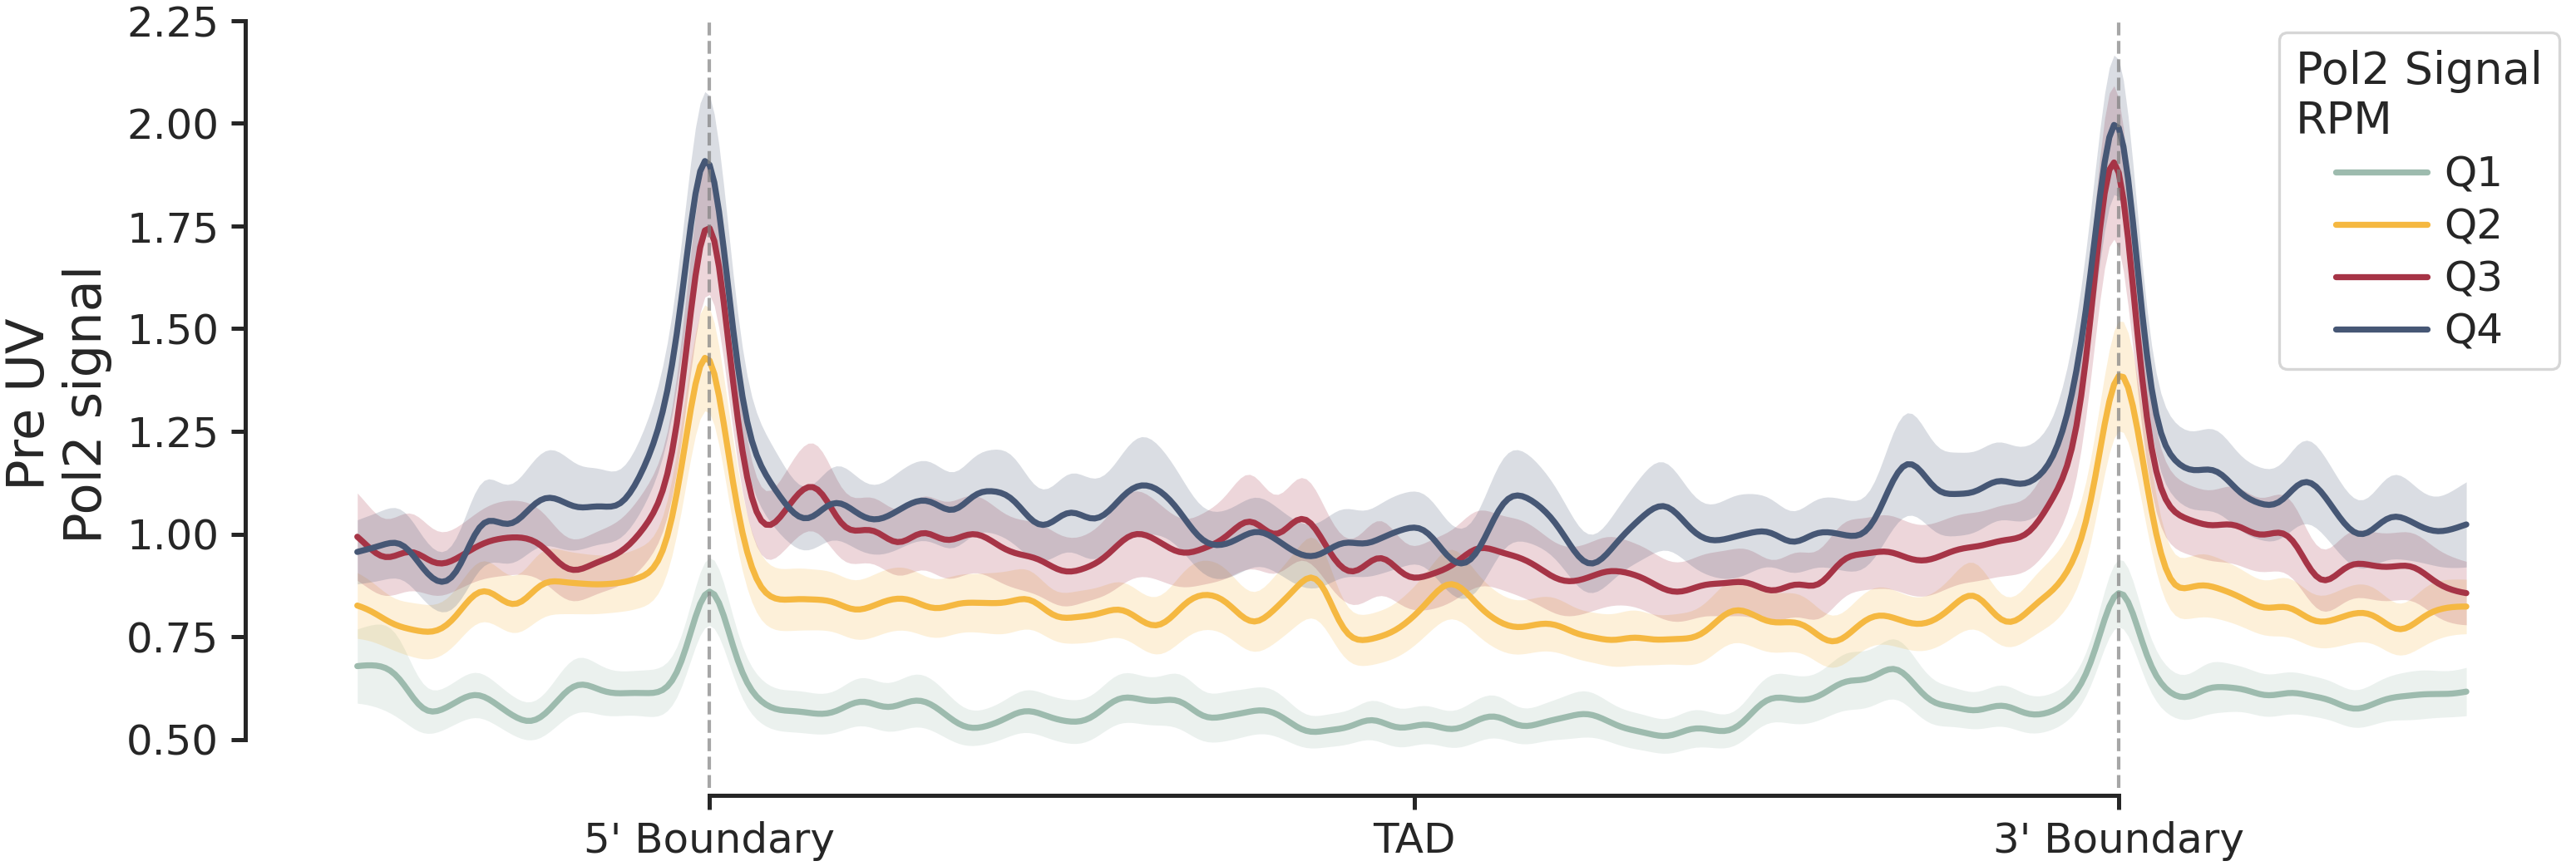

In [45]:
# u2os pol2

pol2_wt_dict = {
    'wt_nouv_pol2': ["/home/carlos/Clone/ggner-3d/misc/GSM7162996_NCRNAPolIIChIP.primary.ucsc.bw"]}

# q stackups - TADS

pol2_nouv_stackup_tads_q = stackup_bw_dict_q(pol2_wt_dict['wt_nouv_pol2'], tads, q_col='ds_Q', mean_per_q=False, nbins=450)

colors = list(reversed(plotting.COLORS))
fig, ax = plt.subplots(1, 1, figsize=(12, 4), sharex='col')

common_params = {
    'plot_kwargs': {'linewidth': 1.75},
    'colors': list(reversed(plotting.COLORS)),
    'smooth_sigma': 3.5,
}

lineplot_stackup_dict(
    pol2_nouv_stackup_tads_q,
    ax=ax,
    labels={
        1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'
    },
    legend_title='Pol2 Signal\nRPM',
    y_title='Pre UV\nPol2 signal',
    structure_type='TAD',
    **common_params
)

# make all tick labels bigger
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plotting.despine(ax)

fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig5/fig5_pol2_u2os.png', bbox_inches='tight')
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig5/fig5_pol2_u2os.svg', bbox_inches='tight')